## Importing libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_validate
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    precision_recall_curve
)

import joblib

%matplotlib inline

# Cardiac Disease Prediction

## Objective

The objective of this project is to develop a machine learning classification
system that predicts the target class using patient-related clinical features.

The project covers:

- Exploratory Data Analysis
- Data preprocessing
- Feature engineering
- Model training
- Hyperparameter tuning
- Cross-validation
- Model evaluation
- Model interpretability
- Model deployment using Streamlit

In [2]:
# Set the resolution of the plotted figures
plt.rcParams['figure.dpi'] = 200

# Configure Seaborn plot styles: Set background color and use dark grid
sns.set(rc={'axes.facecolor': '#faded9'}, style='darkgrid')

In [3]:
# Read dataset
df = pd.read_csv('heart.csv')
df.head() 

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns")

display(df.head())

Dataset contains 303 rows and 14 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
# Display a concise summary of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


## Adding a Target Distribution 
- To check if the data is balanced or imbalanced

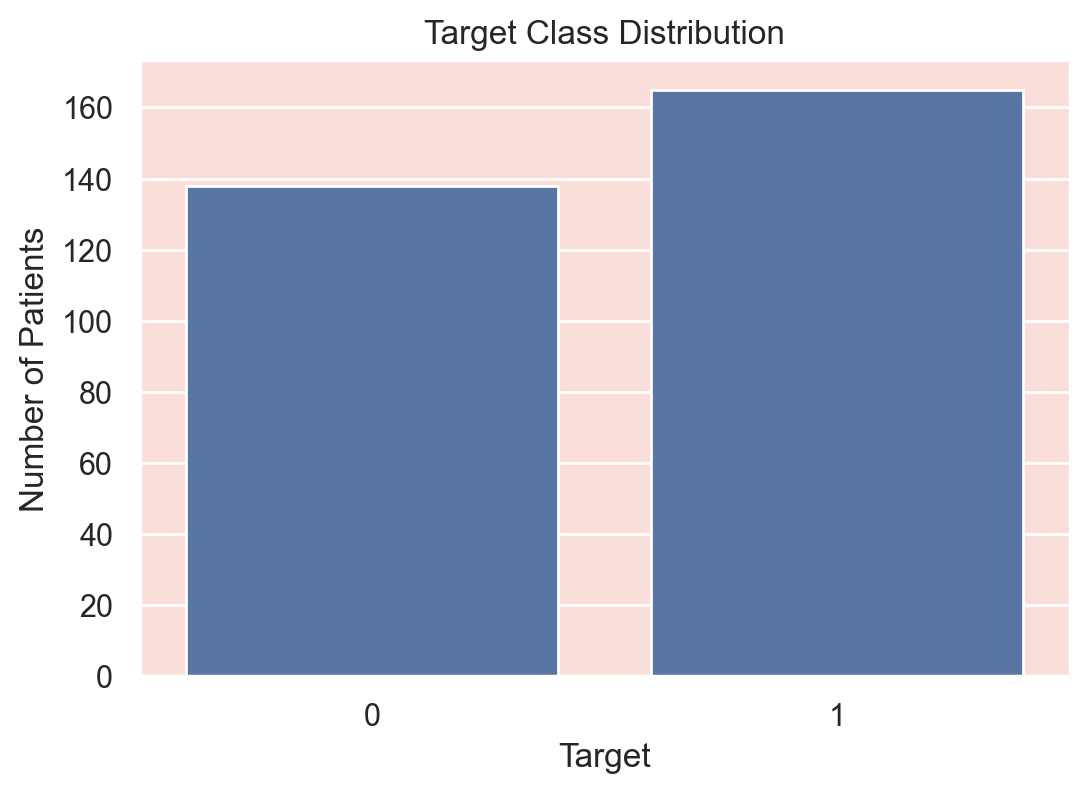

target
1    165
0    138
Name: count, dtype: int64
target
1    54.455446
0    45.544554
Name: proportion, dtype: float64


In [6]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="target")

plt.title("Target Class Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Patients")

plt.show()

print(df["target"].value_counts())
print(df["target"].value_counts(normalize=True) * 100)

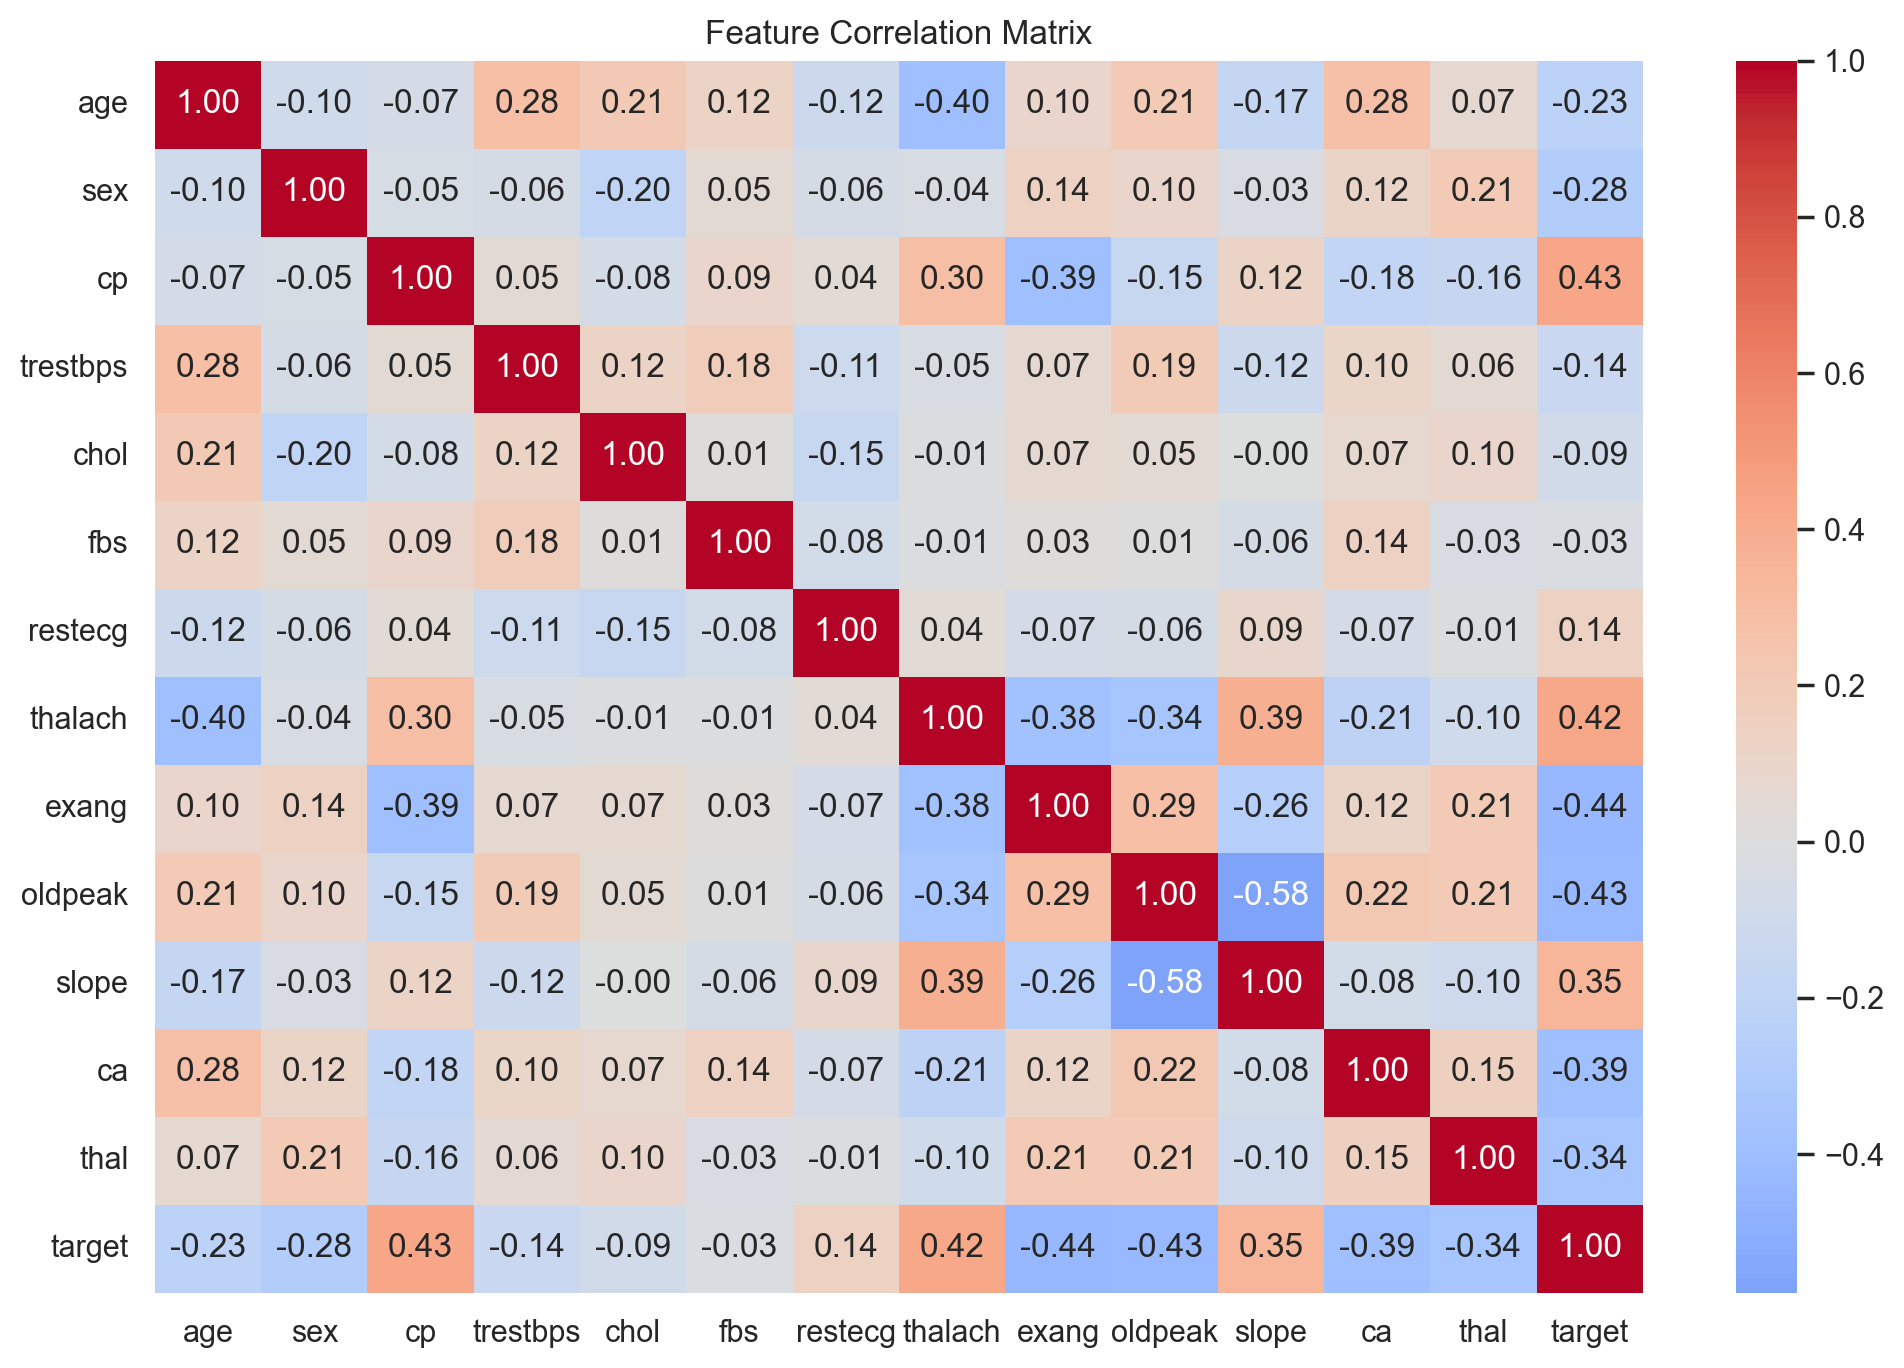

In [7]:
plt.figure(figsize=(12, 8))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.show()

## Train - Test Split

In [8]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (242, 13)
Testing set: (61, 13)


In [9]:
numeric_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

## Creating a Preprocessing Pipeline

In [10]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        drop="first"
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [11]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (242, 22)
Processed testing shape: (61, 22)


## Build Model Pipelines

In [12]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42
    ))
])

In [13]:
knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier())
])

In [14]:
svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(
        probability=True,
        random_state=42
    ))
])

In [15]:
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42
    ))
])

In [16]:
rf_param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [2, 3, 4, 5],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=cv,
    scoring="recall",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

print("Best Parameters:")
print(rf_grid.best_params_)

print("\nBest CV Recall:")
print(rf_grid.best_score_)

Best Parameters:
{'model__max_depth': 2, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best CV Recall:
0.8561253561253561


In [17]:
svm_param_grid = {
    "model__C": [0.1, 1, 10, 100],
    "model__gamma": ["scale", "auto"],
    "model__kernel": ["rbf", "linear"]
}

svm_grid = GridSearchCV(
    svm_pipeline,
    svm_param_grid,
    cv=cv,
    scoring="recall",
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

best_svm = svm_grid.best_estimator_

print("Best Parameters:")
print(svm_grid.best_params_)

print("Best CV Recall:")
print(svm_grid.best_score_)

Best Parameters:
{'model__C': 0.1, 'model__gamma': 'auto', 'model__kernel': 'rbf'}
Best CV Recall:
0.8706552706552706


In [18]:
knn_param_grid = {
    "model__n_neighbors": range(3, 16),
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]
}

knn_grid = GridSearchCV(
    knn_pipeline,
    knn_param_grid,
    cv=cv,
    scoring="recall",
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)

best_knn = knn_grid.best_estimator_

print(knn_grid.best_params_)
print(knn_grid.best_score_)

{'model__n_neighbors': 15, 'model__p': 2, 'model__weights': 'uniform'}
0.8712250712250713


In [19]:
dt_param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [2, 3, 4, 5],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

dt_grid = GridSearchCV(
    dt_pipeline,
    dt_param_grid,
    cv=cv,
    scoring="recall",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_

print(dt_grid.best_params_)
print(dt_grid.best_score_)

{'model__criterion': 'gini', 'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
0.7877492877492878


## Evaluation Function

In [20]:
def evaluate_model(model, X_test, y_test, model_name):

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    }

    return metrics

In [21]:
results = []

results.append(
    evaluate_model(best_dt, X_test, y_test, "Decision Tree")
)

results.append(
    evaluate_model(best_rf, X_test, y_test, "Random Forest")
)

results.append(
    evaluate_model(best_knn, X_test, y_test, "KNN")
)

results.append(
    evaluate_model(best_svm, X_test, y_test, "SVM")
)

results_df = pd.DataFrame(results)

results_df.round(3)

  File "C:\Users\mradu\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\mradu\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\mradu\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\mradu\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Decision Tree,0.721,0.690,0.879,0.773,0.720,0.685
1,Random Forest,0.721,0.700,0.848,0.767,0.852,0.886
2,KNN,0.787,0.794,0.818,0.806,0.857,0.863
3,SVM,0.787,0.778,0.848,0.812,0.865,0.882


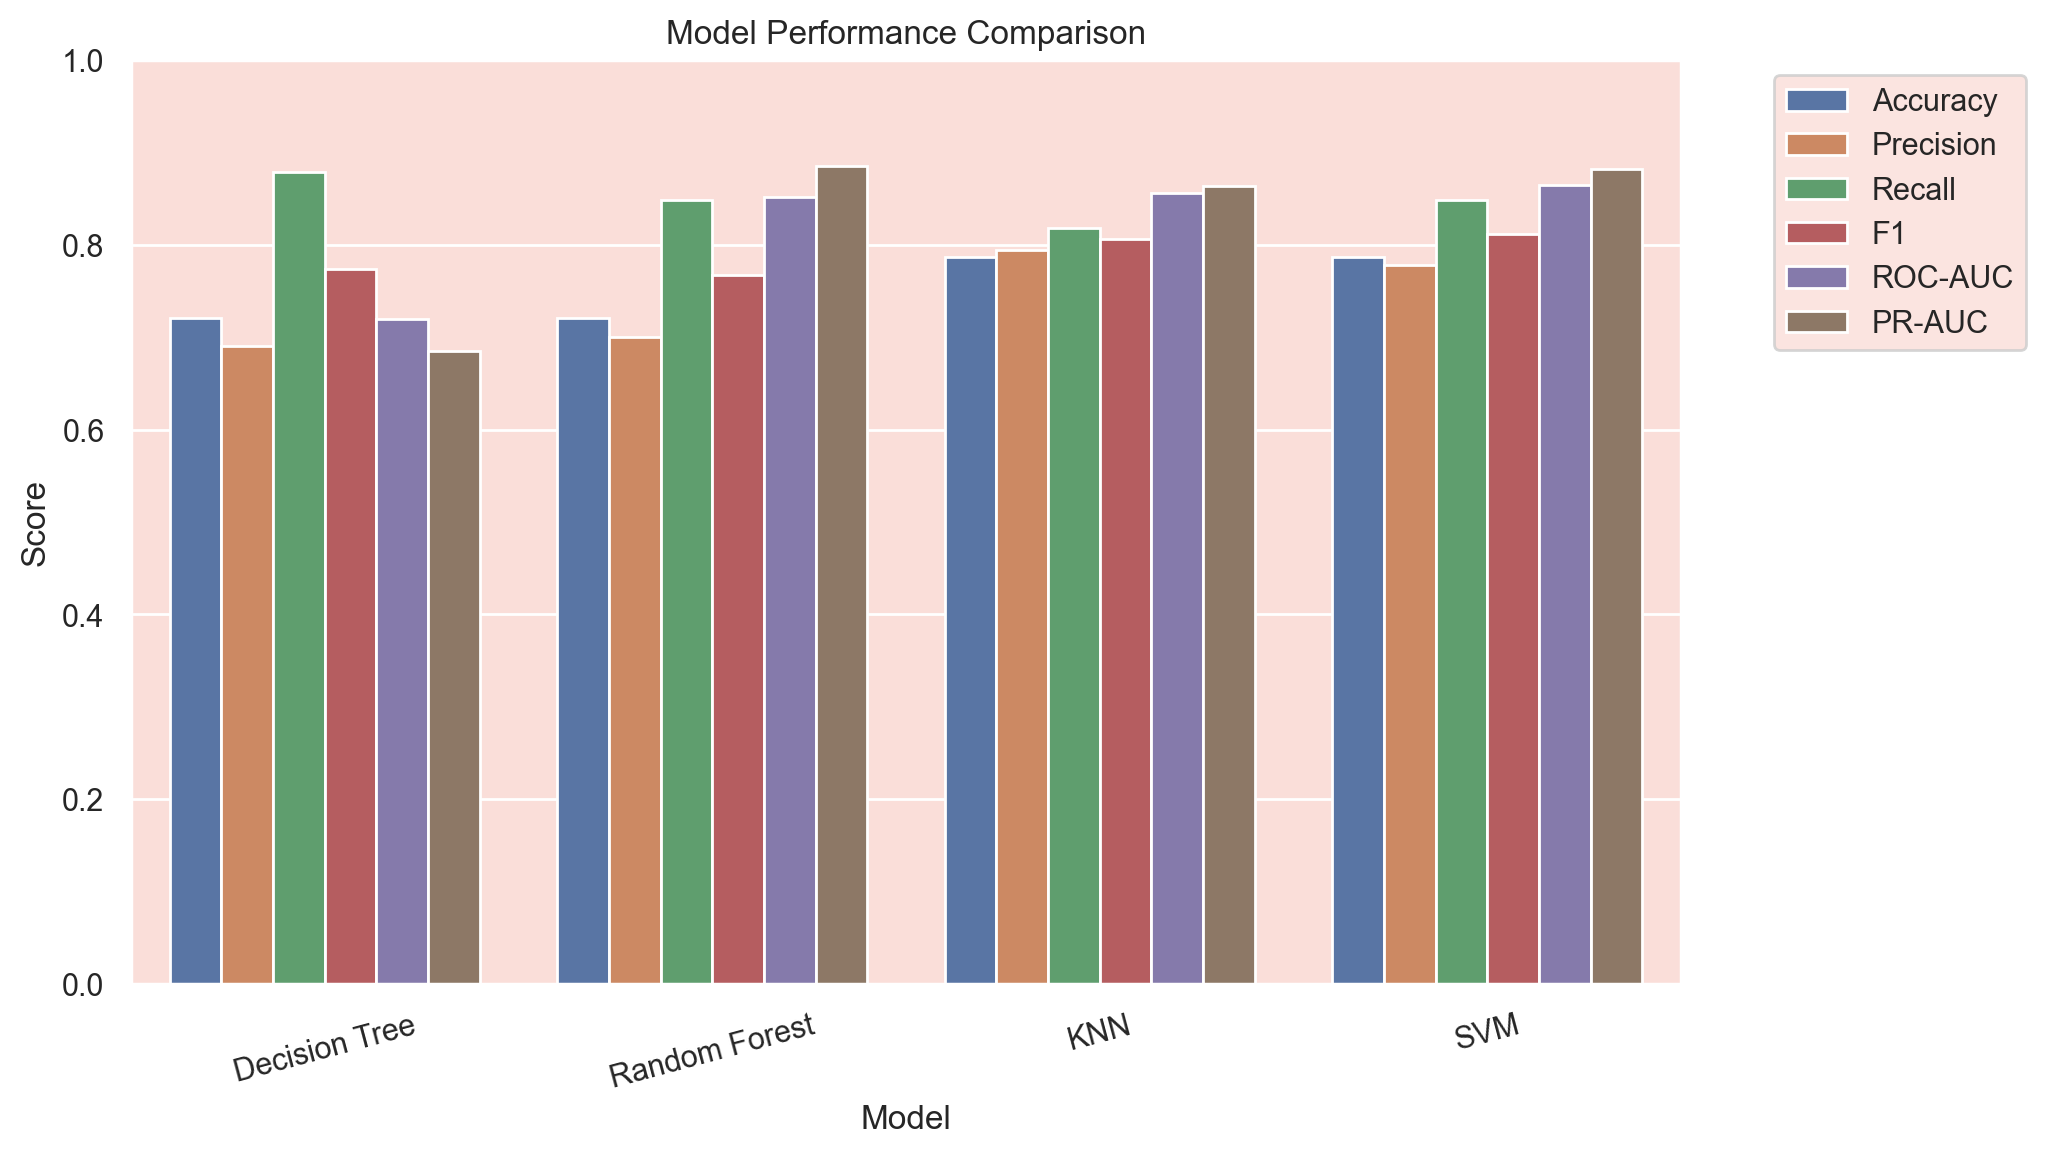

In [22]:
plt.figure(figsize=(10, 6))

results_melted = results_df.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC"
    ],
    var_name="Metric",
    value_name="Score"
)

sns.barplot(
    data=results_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.ylim(0, 1)
plt.title("Model Performance Comparison")
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

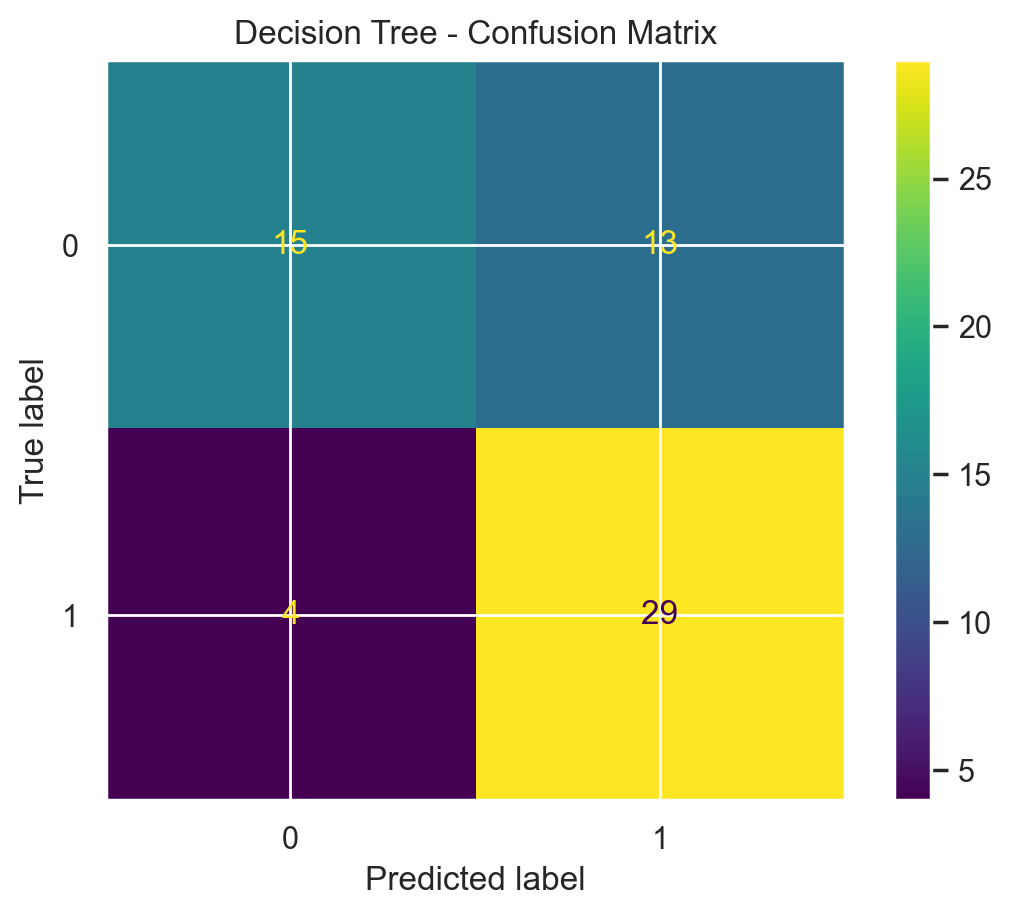

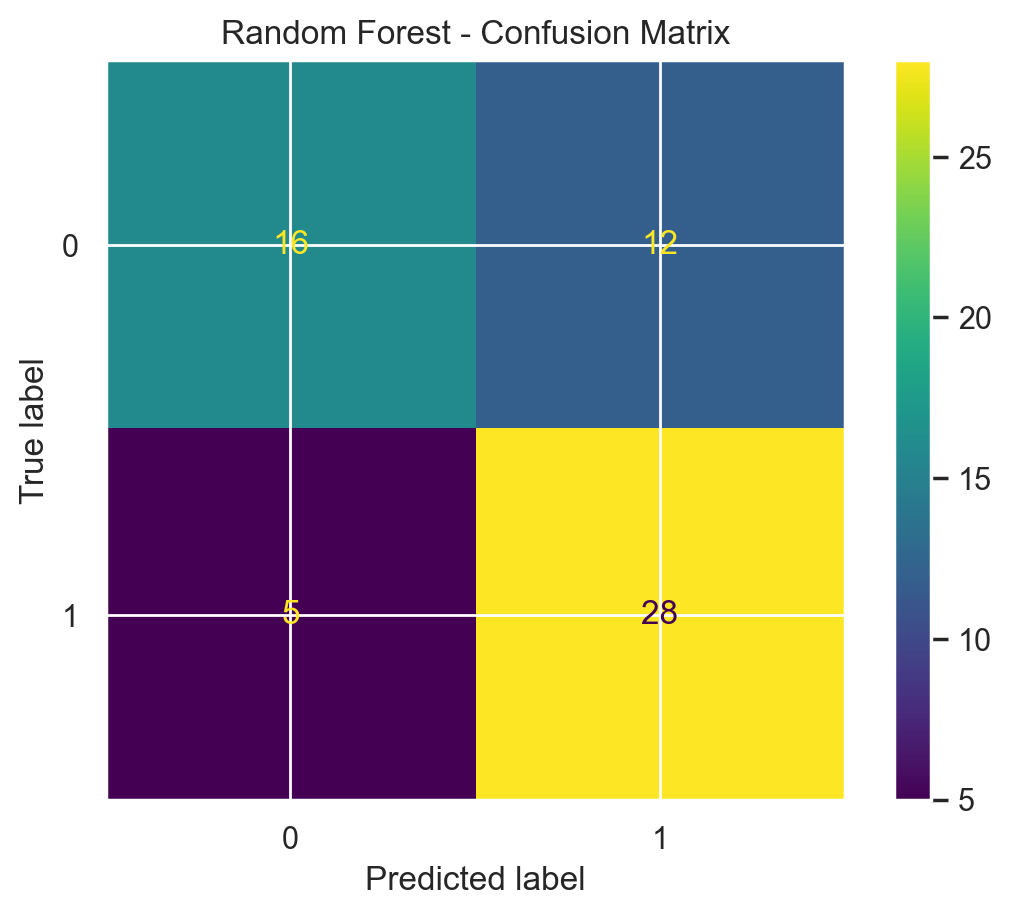

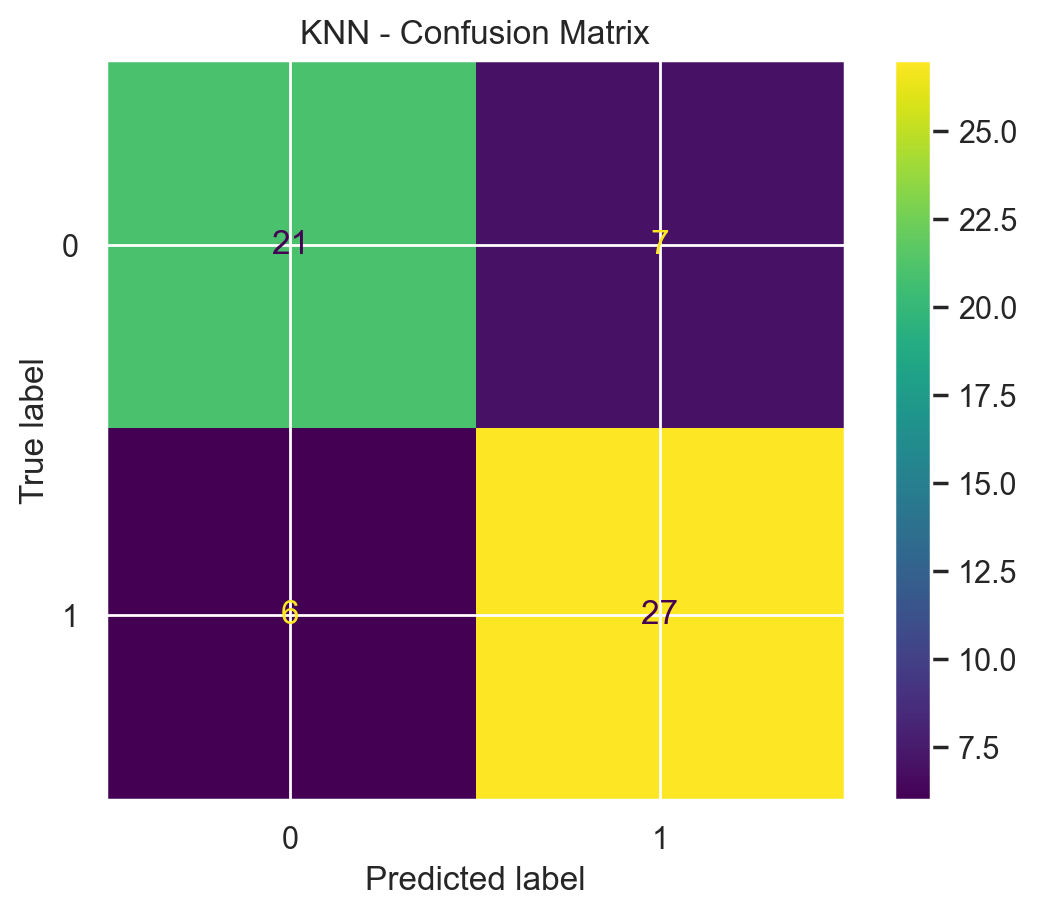

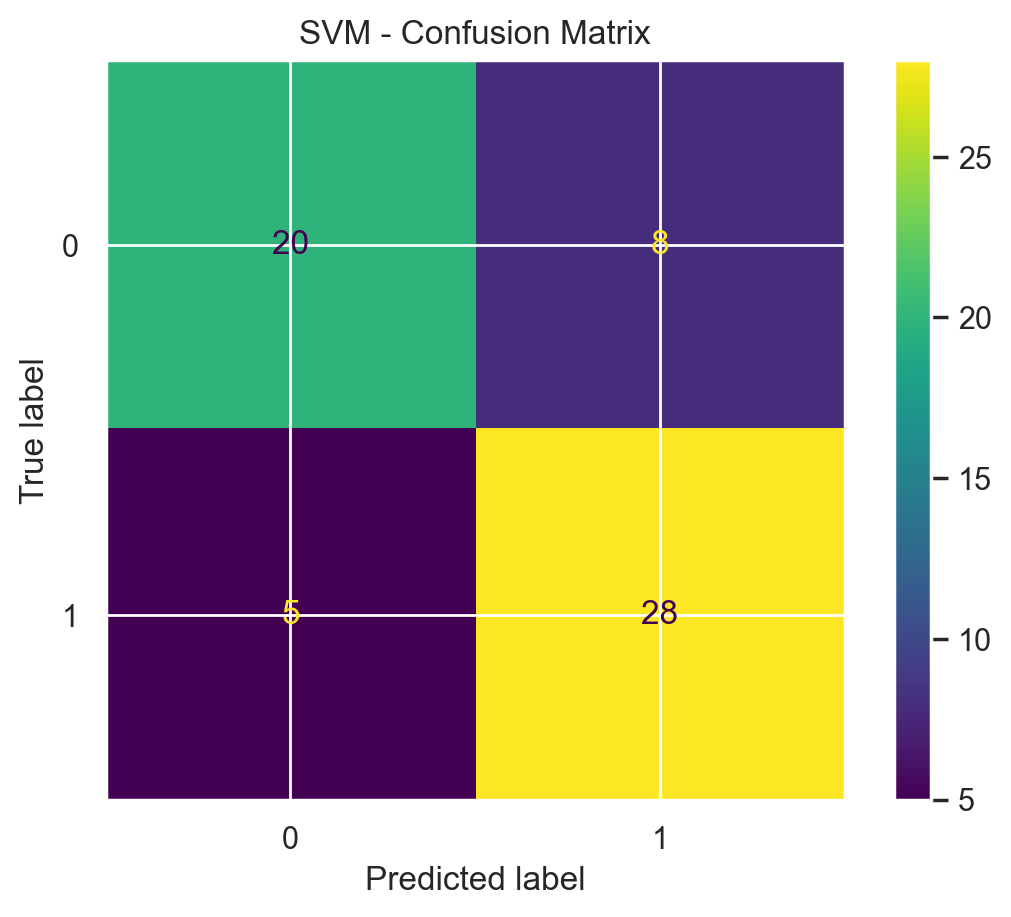

In [23]:
models = {
    "Decision Tree": best_dt,
    "Random Forest": best_rf,
    "KNN": best_knn,
    "SVM": best_svm
}

for name, model in models.items():

    y_pred = model.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred
    )

    plt.title(f"{name} - Confusion Matrix")
    plt.show()

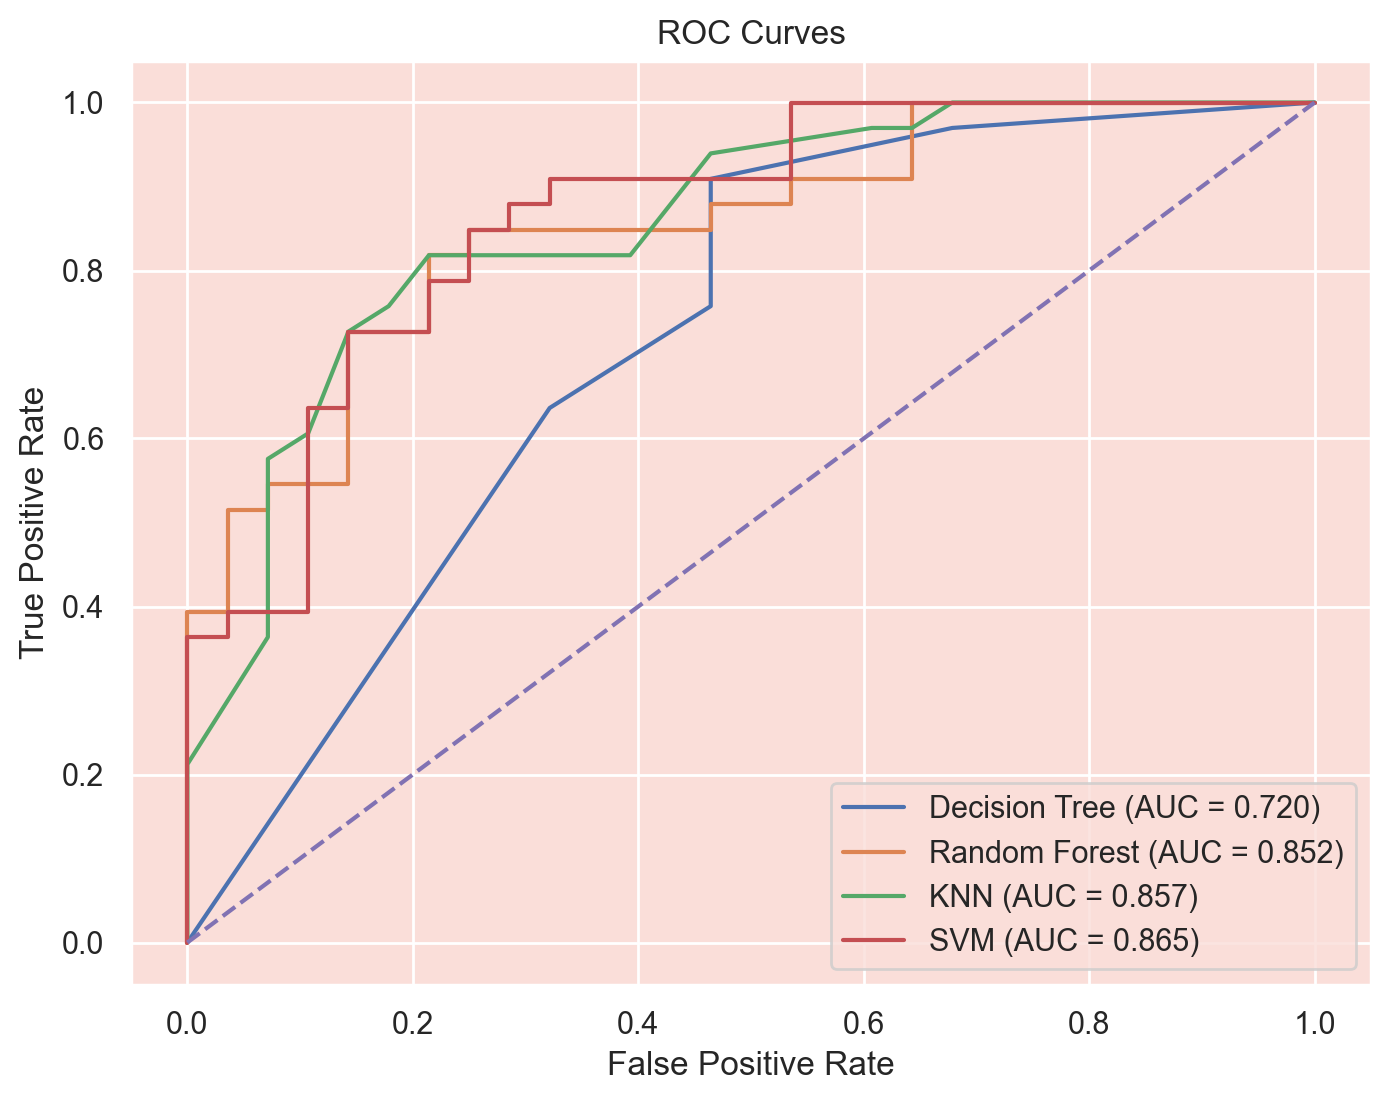

In [24]:
plt.figure(figsize=(8, 6))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()

plt.show()

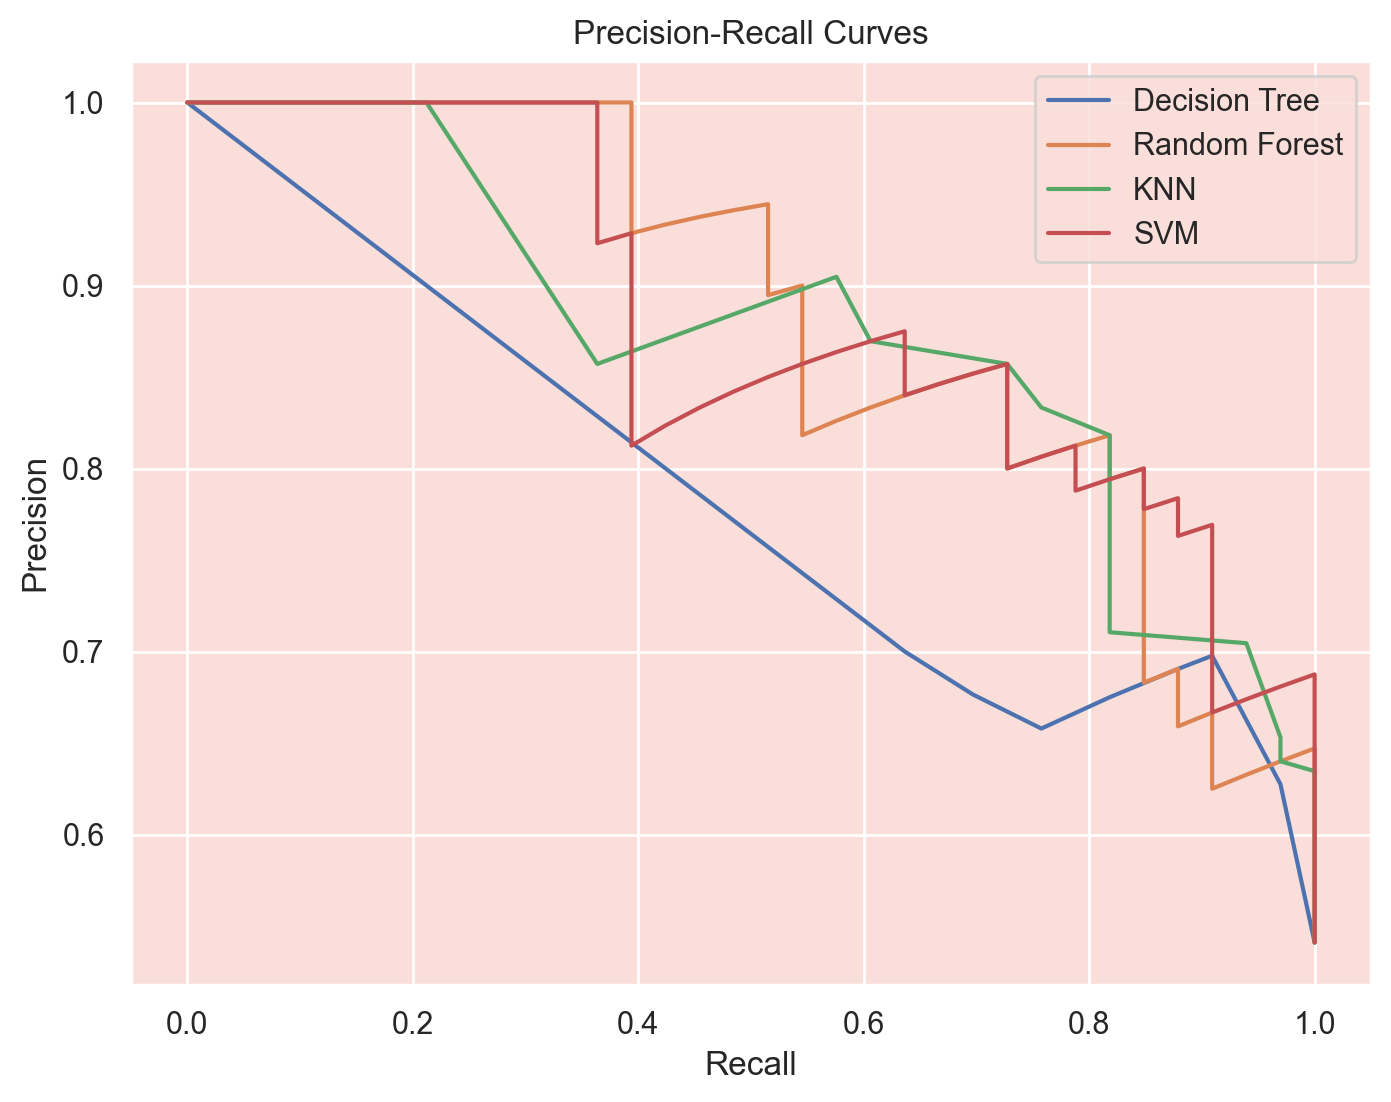

In [25]:
plt.figure(figsize=(8, 6))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(
        y_test,
        y_prob
    )

    plt.plot(
        recall,
        precision,
        label=name
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()

plt.show()

## Adding threshold analysis

In [26]:
best_model = best_rf

y_prob = best_model.predict_proba(X_test)[:, 1]

In [27]:
thresholds = np.arange(0.1, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            y_pred_threshold
        ),
        "Recall": recall_score(
            y_test,
            y_pred_threshold
        ),
        "F1": f1_score(
            y_test,
            y_pred_threshold
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.540984,1.000000,0.702128
1,0.15,0.540984,1.000000,0.702128
2,0.20,0.559322,1.000000,0.717391
3,0.25,0.589286,1.000000,0.741573
4,0.30,0.589286,1.000000,0.741573
5,0.35,0.611111,1.000000,0.758621
6,0.40,0.640000,0.969697,0.771084
7,0.45,0.682927,0.848485,0.756757
8,0.50,0.700000,0.848485,0.767123
9,0.55,0.756757,0.848485,0.800000


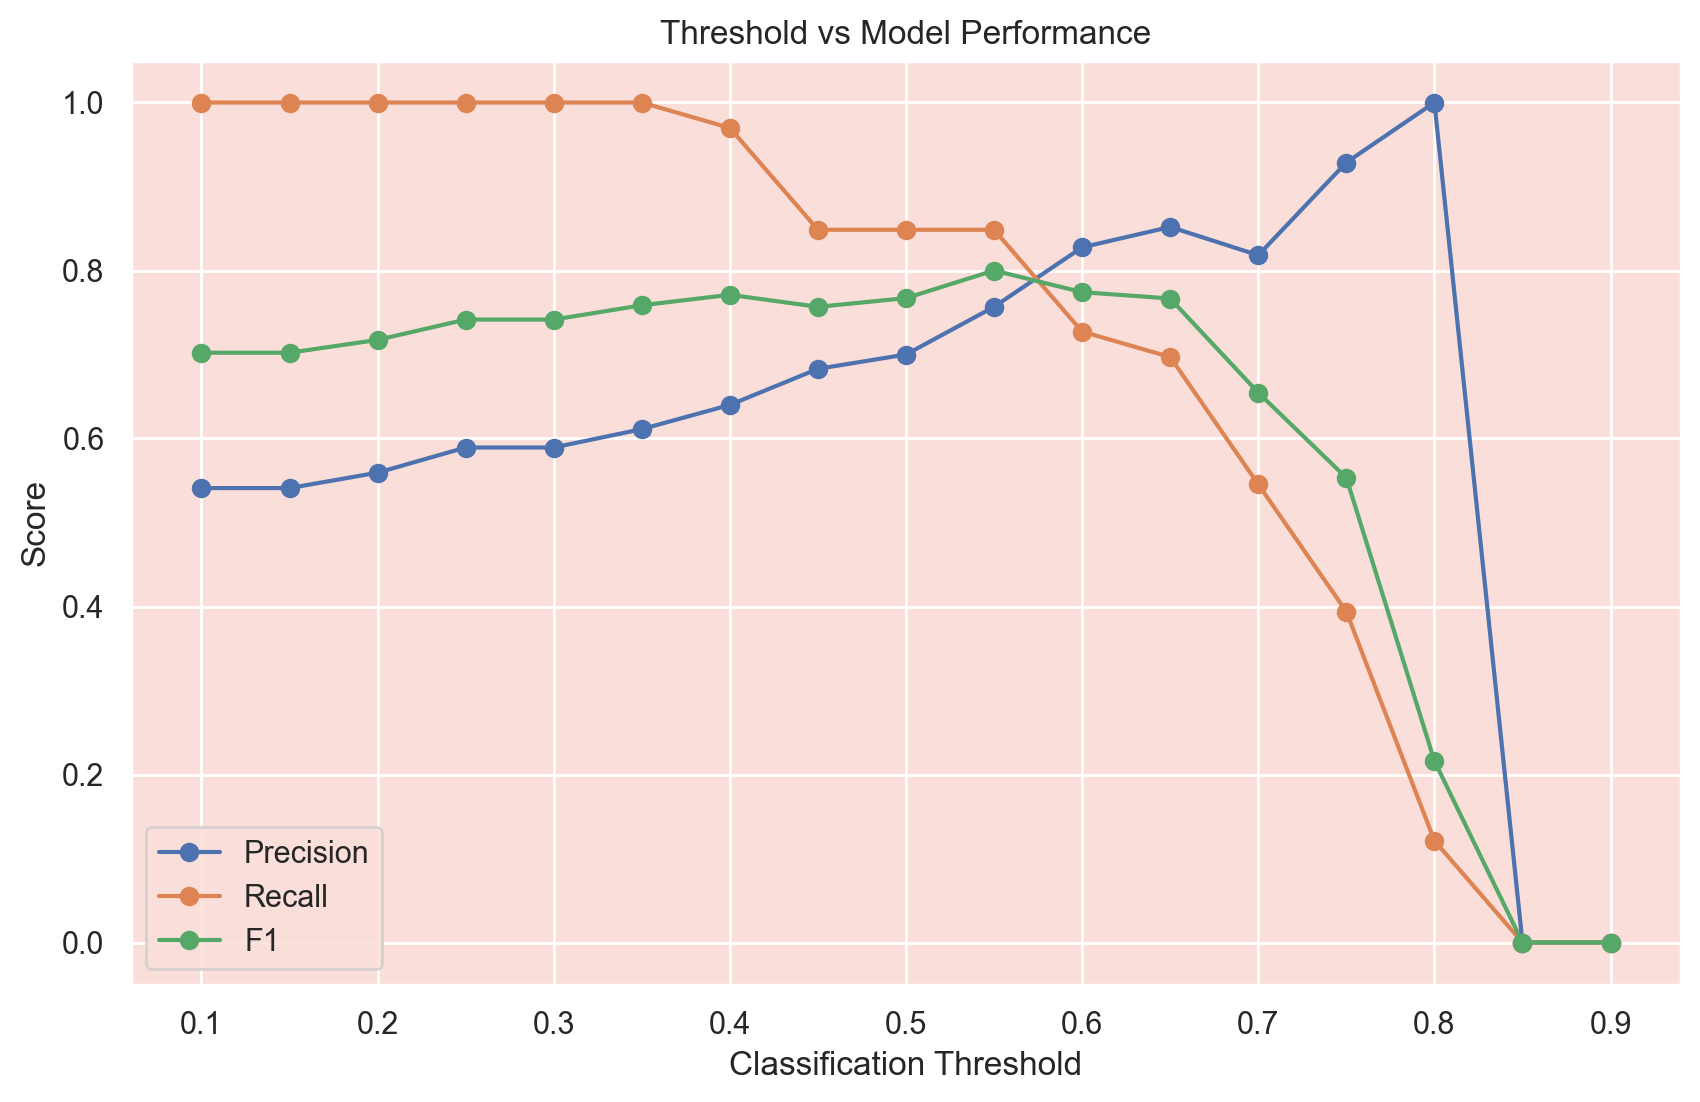

In [28]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"

)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Model Performance")
plt.legend()

plt.show()

In [29]:
rf_preprocessor = best_rf.named_steps["preprocessor"]

rf_model = best_rf.named_steps["model"]

feature_names = rf_preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
20,cat__thal_2,0.200231
21,cat__thal_3,0.147565
4,num__oldpeak,0.123692
12,cat__exang_1,0.109979
3,num__thalach,0.100246
14,cat__slope_2,0.097937
7,cat__cp_2,0.051182
13,cat__slope_1,0.042705
0,num__age,0.033548
5,cat__sex_1,0.017412


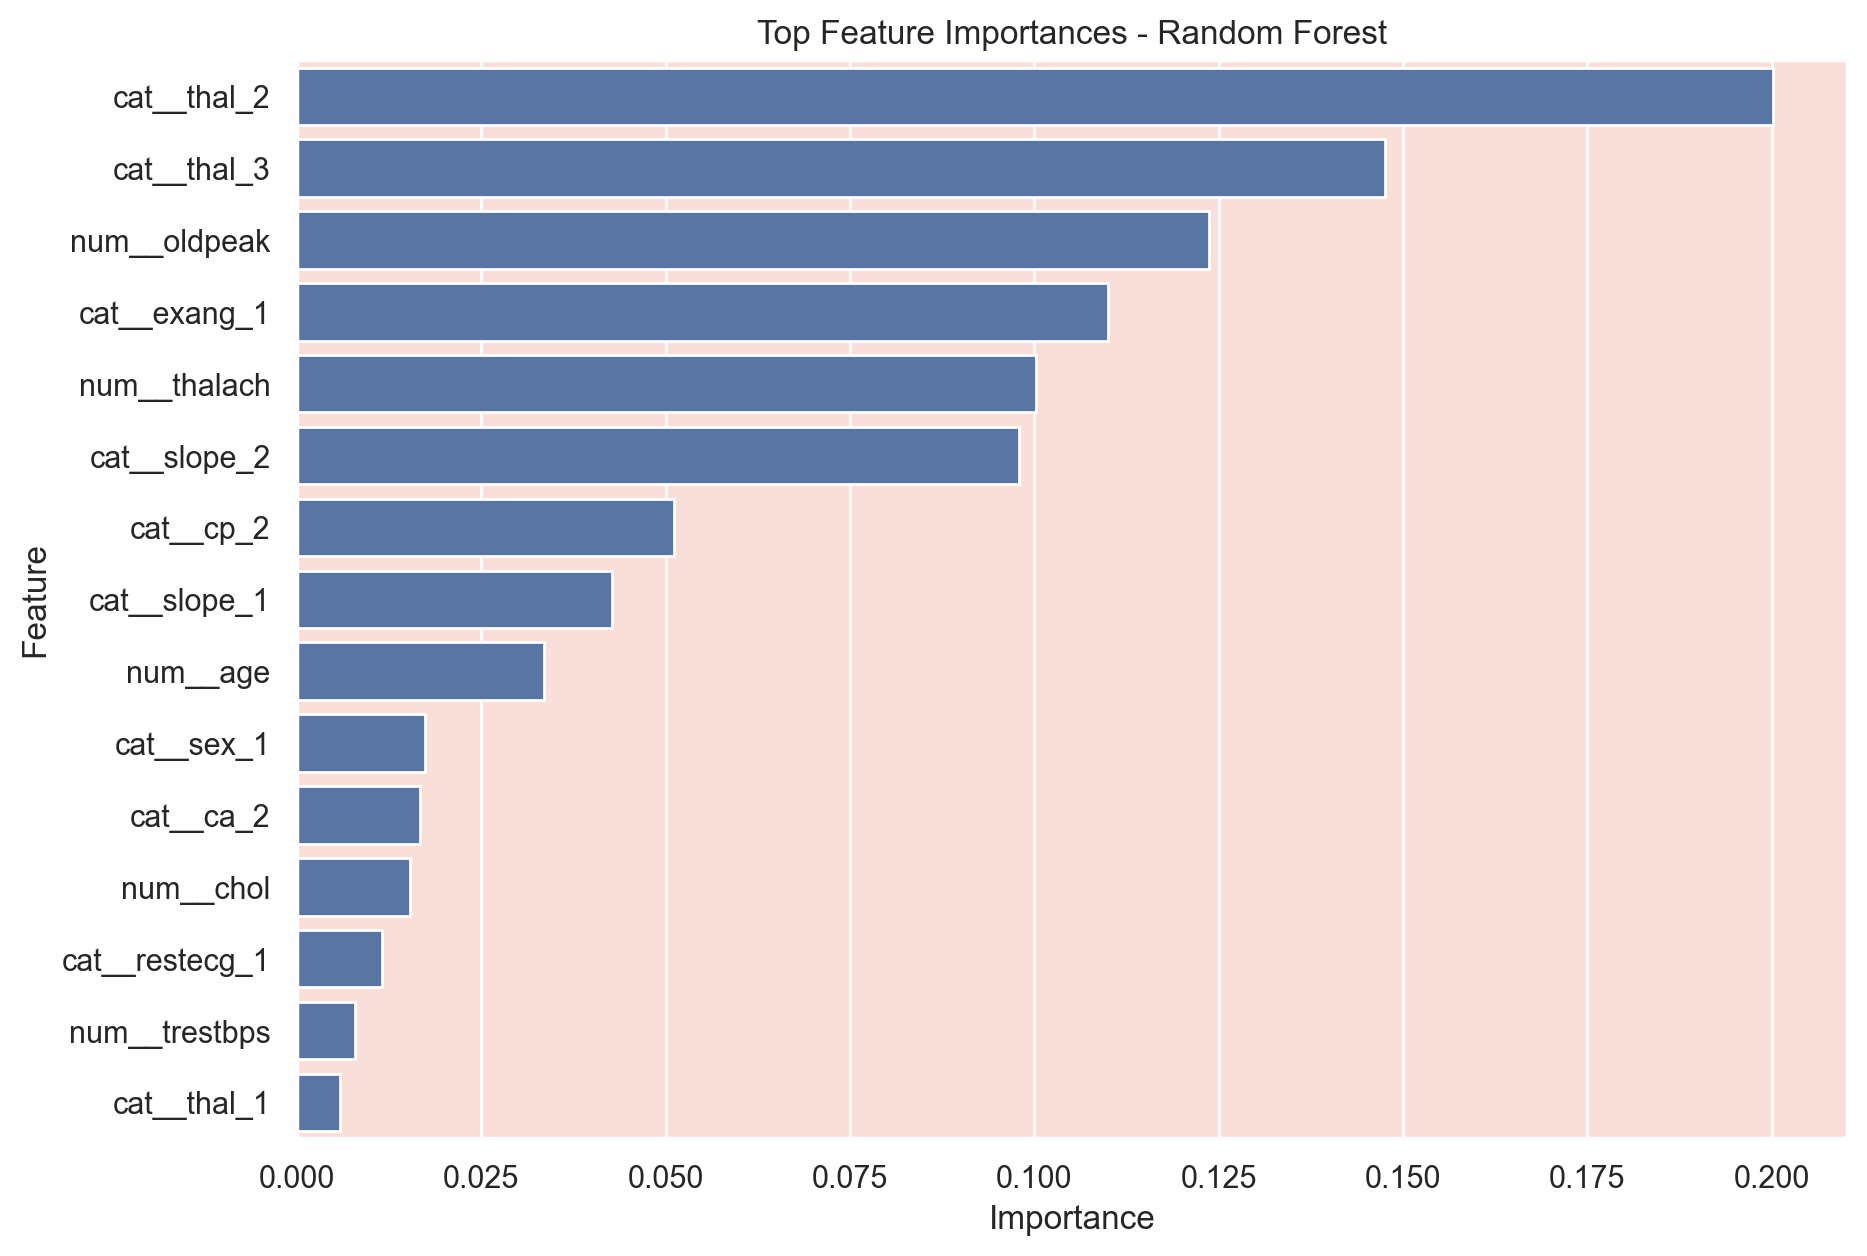

In [30]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top Feature Importances - Random Forest")
plt.show()

In [31]:
cv_results = cross_validate(
    best_rf,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    n_jobs=-1
)

cv_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Mean": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_roc_auc"].mean()
    ],
    "Std": [
        cv_results["test_accuracy"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std(),
        cv_results["test_roc_auc"].std()
    ]
})

cv_summary.round(3)

,Metric,Mean,Std
0,Accuracy,0.797,0.073
1,Precision,0.793,0.071
2,Recall,0.856,0.051
3,F1,0.823,0.060
4,ROC-AUC,0.865,0.059


## Saving Model

In [32]:
import os

os.makedirs("models", exist_ok=True)

joblib.dump(
    best_rf,
    "models/cardiac_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [33]:
loaded_model = joblib.load(
    "models/cardiac_model.pkl"
)

sample_prediction = loaded_model.predict(
    X_test.iloc[[0]]
)

sample_probability = loaded_model.predict_proba(
    X_test.iloc[[0]]
)[0][1]

print("Prediction:", sample_prediction[0])
print("Probability:", round(sample_probability, 3))

Prediction: 0
Probability: 0.357


## Final Prediction Function

In [34]:
def predict_cardiac_risk(patient_data, model):

    prediction = model.predict(patient_data)[0]

    probability = model.predict_proba(
        patient_data
    )[0][1]

    return prediction, probability

In [35]:
sample = X_test.iloc[[0]]

prediction, probability = predict_cardiac_risk(
    sample,
    loaded_model
)

print("Prediction:", prediction)
print("Positive-class probability:", probability)

Prediction: 0
Positive-class probability: 0.35747853938959323


In [36]:
def predict_cardiac_risk(patient_data, model):

    prediction = model.predict(patient_data)[0]

    probability = model.predict_proba(
        patient_data
    )[0][1]

    if prediction == 1:
        result = "Higher Risk"
    else:
        result = "Lower Risk"

    return {
        "prediction": prediction,
        "probability": probability,
        "result": result
    }

In [37]:
sample = X_test.iloc[[0]]

result = predict_cardiac_risk(
    sample,
    loaded_model
)

print("Prediction:", result["prediction"])
print(
    "Positive-class probability:",
    round(result["probability"] * 100, 2),
    "%"
)
print("Result:", result["result"])

Prediction: 0
Positive-class probability: 35.75 %
Result: Lower Risk


In [38]:
patient = pd.DataFrame({
    "age": [55],
    "sex": [1],
    "cp": [2],
    "trestbps": [140],
    "chol": [250],
    "fbs": [0],
    "restecg": [1],
    "thalach": [150],
    "exang": [0],
    "oldpeak": [1.0],
    "slope": [1],
    "ca": [0],
    "thal": [2]
})

patient

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,55,1,2,140,250,0,1,150,0,1.0,1,0,2


In [39]:
result = predict_cardiac_risk(
    patient,
    loaded_model
)

print("Prediction:", result["prediction"])
print(
    "Positive-class probability:",
    round(result["probability"] * 100, 2),
    "%"
)
print("Result:", result["result"])

Prediction: 1
Positive-class probability: 66.61 %
Result: Higher Risk


In [40]:
import json

feature_info = {
    "numeric_features": numeric_features,
    "categorical_features": categorical_features
}

with open("models/feature_info.json", "w") as f:
    json.dump(feature_info, f, indent=4)

print("Feature information saved successfully.")

Feature information saved successfully.


> **Disclaimer:** This project is intended for educational and machine-learning demonstration purposes only. It is not a clinically validated diagnostic tool and should not be used as a substitute for professional medical advice.